<a href="https://colab.research.google.com/github/crowell97/ES5201/blob/main/ES5201_Lecture10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Ray Theory & Seismic Phases — A Companion Notebook

**EARTH 5201 — Introduction to Seismology**

**The Ohio State University**

**Companion notebook to Lecture 10 — Advanced Ray Theory & Seismic Phases**

This notebook turns every derivation from lecture into working code:

1. **Spherical ray tracing from scratch** — implementing the spherical ray equation derived in lecture, which conserves $p_{sph} = r\,u\sin\theta$ along the path.
2. **The core shadow zone, computed directly** — sweeping ray parameters to reproduce the ~100° cutoff for direct P waves, and the real global ray-path figure shown in lecture.
3. **The Earth-flattening transformation** — verified against the lecture's worked PREM example.
4. **A simple 3-D ray tracer** — solving the two coupled first-order ray-tracing equations, and checking that it reduces to the 1-D case (Lecture 9) when velocity varies only with depth.

## 0. Setup

In [15]:
import numpy as np
import matplotlib.pylab as plt

plt.rcParams["figure.figsize"] = (8, 6)

## Part 1 — Spherical Ray Tracing from Scratch

Lecture derived the spherical ray-tracing equation directly from conservation of $p_{sph}=r\,u\sin\theta$:

$$\frac{d\Delta}{dr} = \frac{p_{sph}}{r\sqrt{(ur)^2 - p_{sph}^2}}$$

Stepping inward in radius and accumulating $\Delta$ (the angular distance) at each step gives a complete ray tracer for any spherically symmetric velocity model — no closed-form integral required.

In [16]:
def trace_spherical_ray(p_sph, velocity, r_start, r_stop=0.0, dr=1.0):
    """Trace one leg (down-going) of a spherical ray from r_start inward.

    Conserves p_sph = r*u*sin(theta) at every step. Stops at the turning
    point (where (u*r) = p_sph) or at r_stop, whichever comes first.
    Returns the accumulated angular distance (radians) and the radius reached.
    """
    r, Delta = r_start, 0.0
    while r > r_stop:
        u = 1.0 / velocity(r)
        arg = (u * r) ** 2 - p_sph ** 2
        if arg <= 1e-6:
            break  # turning point reached
        dDelta_dr = p_sph / (r * np.sqrt(arg))
        Delta += dDelta_dr * dr
        r -= dr
    return Delta, r

In [17]:
# Try it on a simple linear-gradient mantle model
Re = 6371.0
def velocity_gradient(r):
    return 8.0 + (13.7 - 8.0) * (Re - r) / (Re - 3480.0)  # 8 km/s at surface, 13.7 at CMB

p_sph = 0.5 * (Re / velocity_gradient(Re))   # half the grazing ray parameter
Delta, r_turn = trace_spherical_ray(p_sph, velocity_gradient, Re)
print(f"Turning radius: {r_turn:.0f} km  (turning depth: {Re - r_turn:.0f} km)")
print(f"One-way angular distance: {np.degrees(Delta):.2f} degrees")
print(f"Full (two-way) distance: {2*np.degrees(Delta):.2f} degrees")

Turning radius: 4586 km  (turning depth: 1785 km)
One-way angular distance: 30.22 degrees
Full (two-way) distance: 60.44 degrees


### Visualizing a fan of rays

Just like the flat-Earth ray fans from Lecture 9, we can trace many rays at once and plot them as a cross-section of the Earth.

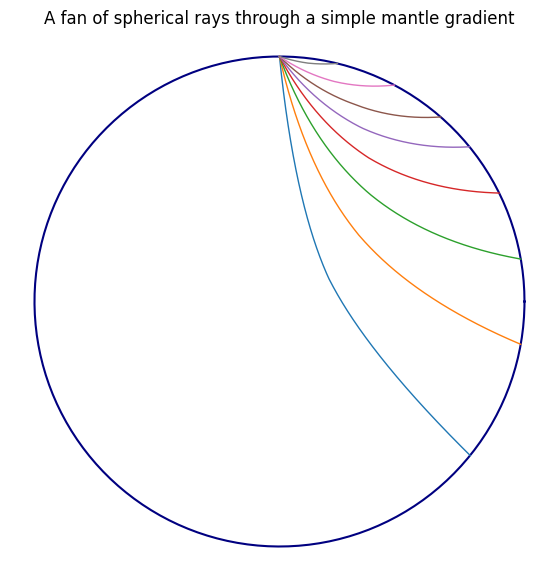

In [18]:
def full_leg(p_sph, velocity, r_start, r_stop=0.0, dr=1.0):
    """Down-going then mirrored up-going leg, for a complete turning ray."""
    r, Delta = r_start, 0.0
    Deltas, rs = [0.0], [r]
    while r > r_stop:
        u = 1.0 / velocity(r)
        arg = (u * r) ** 2 - p_sph ** 2
        if arg <= 1e-6:
            break
        Delta += (p_sph / (r * np.sqrt(arg))) * dr
        r -= dr
        Deltas.append(Delta)
        rs.append(r)
    Deltas, rs = np.array(Deltas), np.array(rs)
    Delta_full = np.concatenate([Deltas, Deltas[-1] + (Deltas[-1] - Deltas[::-1][1:])])
    r_full = np.concatenate([rs, rs[::-1][1:]])
    return Delta_full, r_full

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect("equal")
theta_full = np.linspace(0, 2 * np.pi, 300)
ax.plot(Re * np.cos(theta_full), Re * np.sin(theta_full), color="navy")

p_max = Re / velocity_gradient(Re)
for p_sph in np.linspace(0.1 * p_max, 0.95 * p_max, 8):
    D, R = full_leg(p_sph, velocity_gradient, Re)
    ang = np.pi / 2 - D  # start pointing "up" at the source
    x, y = R * np.cos(ang), R * np.sin(ang)
    ax.plot(x, y, linewidth=1)

ax.axis("off")
ax.set_title("A fan of spherical rays through a simple mantle gradient")
plt.show()

## Part 2 — The Core Shadow Zone, Computed Directly

Now let's reproduce the headline result from lecture: direct P waves are only observed out to about 100° from the source, because of the sharp velocity drop at the core-mantle boundary.

In [19]:
R_cmb = 3480.0
R_icb = 1220.0

def velocity_p(r):
    """Simplified global P-velocity model: mantle gradient, outer core, inner core."""
    r = np.asarray(r, dtype=float)
    v_mantle = 8.0 + (13.7 - 8.0) * (Re - r) / (Re - R_cmb)
    v_outer = 8.0 + (10.3 - 8.0) * (R_cmb - r) / (R_cmb - R_icb)
    v_inner = 11.0 + 0.2 * (R_icb - r) / R_icb
    return np.where(r >= R_cmb, v_mantle, np.where(r >= R_icb, v_outer, v_inner))

p_max = Re / velocity_p(Re) * 0.999
distances = []
for p in np.linspace(0.05 * p_max, p_max, 300):
    Delta, r_turn = trace_spherical_ray(p, velocity_p, Re, dr=2.0)
    if r_turn > R_cmb:   # only keep rays that genuinely turned in the mantle
        distances.append(2 * np.degrees(Delta))

print(f"Direct P observed out to {max(distances):.1f} degrees")
print("(Compare to the real Earth's well-known ~100 degree direct-P cutoff)")

Direct P observed out to 103.6 degrees
(Compare to the real Earth's well-known ~100 degree direct-P cutoff)


### Reproducing the global ray-path figure from lecture

Tracing P-only mantle rays alongside rays that are forced to enter the core (PKP, PKIKP) reproduces the same qualitative picture shown in the lecture slides: a gap between where direct P rays stop and where core phases re-emerge.

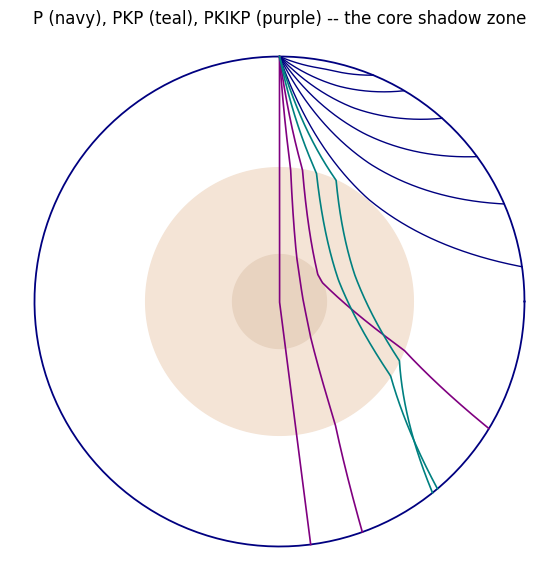

In [20]:
def trace_full_path_into_core(p_sph, dr=2.0, target_step_rad=0.01, r_floor=0.05, max_steps=200000):
    """Full down-going path (mantle + core) as arrays of (Delta, r), then
    mirrored for the complete down-going + up-going ray.

    Near the true turning point (and near r=0 for very small p), the ray
    equation's dDelta/dr = p/(r*sqrt((ur)^2-p^2)) formally diverges, so a
    fixed step size can take one huge, inaccurate step right before the
    loop stops -- which, once mirrored, looks like the ray sharply
    bounces rather than smoothly turning. To avoid this, the step size is
    chosen adaptively so the angular change per step never exceeds
    target_step_rad, however fast dDelta/dr is changing.
    """
    r, Delta = Re, 0.0
    Deltas, rs = [Delta], [r]
    n = 0
    while r > R_cmb and n < max_steps:
        u = 1.0 / velocity_p(r)
        arg = (u * r) ** 2 - p_sph ** 2
        if arg <= 1e-8:
            return None  # turned before reaching the core
        dDelta_dr = p_sph / (r * np.sqrt(arg))
        dr_eff = min(dr, target_step_rad / dDelta_dr)
        Delta += dDelta_dr * dr_eff
        r -= dr_eff
        Deltas.append(Delta)
        rs.append(r)
        n += 1
    r_min = r
    while r > r_floor and n < max_steps:
        u = 1.0 / velocity_p(r)
        arg = (u * r) ** 2 - p_sph ** 2
        if arg <= 1e-8:
            break
        dDelta_dr = p_sph / (r * np.sqrt(arg))
        dr_eff = min(dr, target_step_rad / dDelta_dr)
        Delta += dDelta_dr * dr_eff
        r -= dr_eff
        Deltas.append(Delta)
        rs.append(r)
        r_min = min(r_min, r)
        n += 1
    Deltas, rs = np.array(Deltas), np.array(rs)
    Delta_full = np.concatenate([Deltas, Deltas[-1] + (Deltas[-1] - Deltas[::-1][1:])])
    r_full = np.concatenate([rs, rs[::-1][1:]])
    return Delta_full, r_full, r_min

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect("equal")
theta_full = np.linspace(0, 2 * np.pi, 300)
ax.plot(Re * np.cos(theta_full), Re * np.sin(theta_full), color="navy", linewidth=1.3)
ax.fill(R_cmb * np.cos(theta_full), R_cmb * np.sin(theta_full), color="#F4E4D6", zorder=0)
ax.fill(R_icb * np.cos(theta_full), R_icb * np.sin(theta_full), color="#E8D3C0", zorder=0)

p_min_mantle = R_cmb / velocity_p(R_cmb) * 1.02
for p in np.linspace(p_min_mantle, 0.92 * p_max, 6):
    D, R = full_leg(p, velocity_p, Re)
    ang = np.pi / 2 - D
    ax.plot(R * np.cos(ang), R * np.sin(ang), color="navy", linewidth=1)

for p in np.linspace(0.02, 0.85 * p_min_mantle, 5):
    result = trace_full_path_into_core(p)
    if result is None:
        continue
    Delta_full, r_full, r_min = result
    ang = np.pi / 2 - Delta_full
    x, y = r_full * np.cos(ang), r_full * np.sin(ang)
    color = "purple" if r_min < R_icb else "teal"
    ax.plot(x, y, color=color, linewidth=1.2)

ax.axis("off")
ax.set_title("P (navy), PKP (teal), PKIKP (purple) -- the core shadow zone")
plt.show()

## Part 3 — The Earth-Flattening Transformation

A direct implementation of the depth and velocity transforms derived in lecture:

$$z_f = -a\ln(r/a), \qquad v_f(z_f) = (a/r)\,v_s(r)$$

In [21]:
def earth_flatten(z_s, v_s, a=6371.0):
    """Transform a spherical-Earth (depth, velocity) pair to the flat-Earth equivalent."""
    r = a - z_s
    z_f = -a * np.log(r / a)
    v_f = (a / r) * v_s
    return z_f, v_f

z_f, v_f = earth_flatten(z_s=2000, v_s=12.9)
print(f"z_f = {z_f:.0f} km   (expect 2400)")
print(f"v_f = {v_f:.2f} km/s  (expect 18.80)")

assert abs(z_f - 2400) < 1
assert abs(v_f - 18.80) < 0.01
print("\nMatches the lecture's worked example.")

z_f = 2400 km   (expect 2400)
v_f = 18.80 km/s  (expect 18.80)

Matches the lecture's worked example.


### Visualizing the transformation

Applying the transform across a full velocity profile shows exactly how the "flattened" model differs from the real one — increasingly so with depth, since deeper material gets pushed further out in the flattened coordinate.

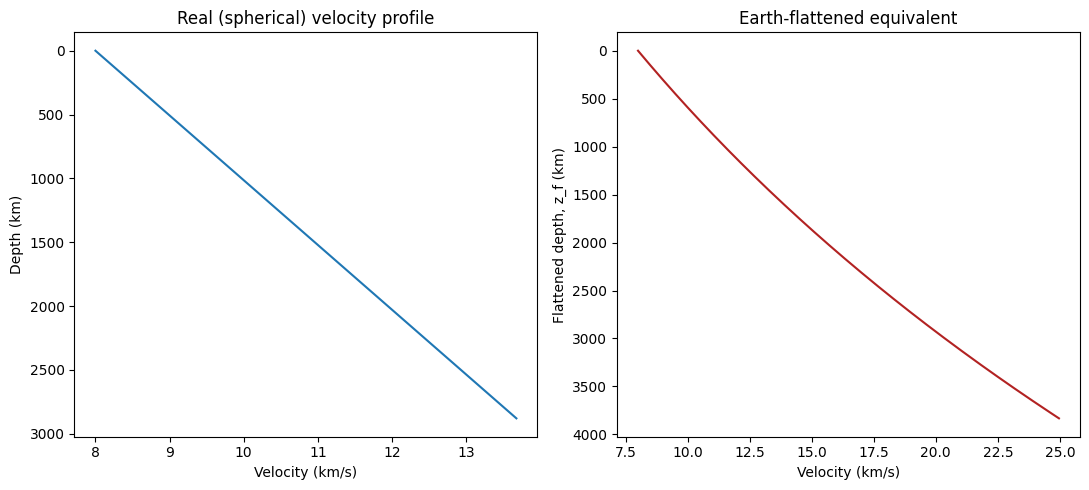

In [22]:
depths = np.linspace(0, 2880, 200)   # down to the CMB
vels = velocity_p(6371 - depths)      # reuse the P-velocity model from Part 2

z_f_arr, v_f_arr = earth_flatten(depths, vels)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].plot(vels, depths, label="spherical (real)")
axes[0].invert_yaxis()
axes[0].set_xlabel("Velocity (km/s)"); axes[0].set_ylabel("Depth (km)")
axes[0].set_title("Real (spherical) velocity profile")

axes[1].plot(v_f_arr, z_f_arr, color="firebrick", label="flattened")
axes[1].invert_yaxis()
axes[1].set_xlabel("Velocity (km/s)"); axes[1].set_ylabel("Flattened depth, z_f (km)")
axes[1].set_title("Earth-flattened equivalent")
plt.tight_layout()
plt.show()

## Part 4 — A Simple 3-D Ray Tracer

Lecture derived two coupled first-order equations from the Eikonal equation:

$$\frac{d\mathbf{s}}{ds} = \nabla u, \qquad \frac{d\mathbf{x}}{ds} = \frac{\mathbf{s}}{u}$$

Let's implement a basic Euler-step solver for these, and confirm it reduces to the 1-D case when the velocity model only varies with depth.

In [23]:
def ray_step_3d(x, s, grad_u_func, u_func, ds_step=0.5):
    """One Euler step of the 3-D ray-tracing equations."""
    u = u_func(x)
    x_next = x + ds_step * s / u       # dx/ds = s/u
    s_next = s + ds_step * grad_u_func(x)  # ds/ds = grad(u)
    return x_next, s_next

def trace_ray_3d(x0, s0, grad_u_func, u_func, n_steps=2000, ds_step=0.5):
    xs = [x0]
    x, s = x0, s0
    for _ in range(n_steps):
        x, s = ray_step_3d(x, s, grad_u_func, u_func, ds_step)
        xs.append(x.copy())
        if x[2] < 0:   # stop once the ray returns to the surface (z=0)
            break
    return np.array(xs)

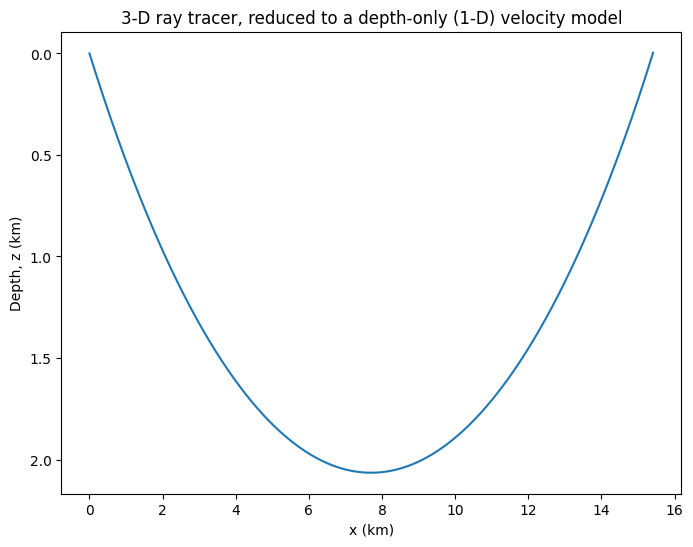

Ray returned to the surface after traveling x = 15.41 km


In [24]:
# A depth-only velocity model: u depends on z alone, so this should
# reduce to the familiar 1-D ray behavior from Lecture 9.
def u_depth_only(x):
    z = x[2]
    v = 4.0 + 0.3 * z
    return 1.0 / v

def grad_u_depth_only(x):
    z = x[2]
    v = 4.0 + 0.3 * z
    dv_dz = 0.3
    du_dz = -dv_dz / v**2
    return np.array([0.0, 0.0, du_dz])

# Launch a ray at some takeoff angle from the vertical
theta0 = np.deg2rad(60)
x0 = np.array([0.0, 0.0, 0.0])
u0 = u_depth_only(x0)
s0 = u0 * np.array([np.sin(theta0), 0.0, np.cos(theta0)])

path = trace_ray_3d(x0, s0, grad_u_depth_only, u_depth_only, n_steps=4000, ds_step=0.01)

plt.plot(path[:, 0], path[:, 2])
plt.gca().invert_yaxis()
plt.xlabel("x (km)"); plt.ylabel("Depth, z (km)")
plt.title("3-D ray tracer, reduced to a depth-only (1-D) velocity model")
plt.show()

print(f"Ray returned to the surface after traveling x = {path[-1,0]:.2f} km")

The ray traces out the same kind of smooth, curving arc we saw in the 1-D ray-tracing notebook from Lecture 9 — confirming the 3-D equations correctly collapse to the 1-D case when there's no horizontal velocity variation, exactly as claimed in lecture.

## Summary & Further Resources

- **Spherical ray tracing** — conserving $p_{sph}=r\,u\sin\theta$ at every step gives a complete ray tracer for any spherically symmetric Earth model.
- **The core shadow zone** — a direct, computed consequence of the sharp velocity drop at the CMB; no direct P/S arrivals appear between roughly 100° and the distance where core phases re-emerge.
- **Earth-flattening** — `z_f = -a*ln(r/a)`, `v_f = (a/r)*v_s` lets any flat-Earth ray-tracing code work correctly on a spherical model.
- **3-D ray tracing** — two coupled first-order ODEs, solvable with basic numerical integration, that reduce exactly to the 1-D case for depth-only models.

**For further reading:**
- Stein, S., and M. Wysession, *An Introduction to Seismology, Earthquakes, and Earth Structure*, Chapter 4 — the standard reference for this lecture's derivations.
- The TauP Toolkit (Crotwell et al., 1999) and ObsPy's `obspy.taup` module — production-quality spherical ray tracing and travel-time calculators built on exactly this theory.
- Astiz, L., D. Earle, and P. Shearer (1996), and Kennett, B. L. N., and E. R. Engdahl (1991) — the sources for the real travel-time and phase-key figures shown in lecture.